# 1. Dataset Sanity & Coverage Checks

* Number of connections per application (long-tail detection)
* Temporal coverage per application (days/weeks active)
* Cardinality of categorical fields (SNI, ALPN, cipher suite, TLS version)

In [1]:
%reload_ext autoreload
%autoreload 2

1. Reading the dataset

Loading the whole dataset and obtaining a fraction of it (approx.30 sec).

In [2]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
import sys
sys.path.append('../../src')

import pyarrow.dataset as ds
from preact_analysis.schema import dataset_schema, dataset_summary 

print("Opening dataset...")
dataset = ds.dataset(f"../../datasets/winapps.parquet", format="parquet", schema=dataset_schema)
dataset_summary(dataset)

print(f"Loading dataset (first 100k rows)...")

table_100k = dataset.head(100_000)
df_100k = table_100k.to_pandas()
df_10k = df_100k.sample(n=10_000, random_state=42)
df_1k = df_100k.sample(n=1_000, random_state=42)
print(f"Data loaded!")

Opening dataset...
=== DATASET SUMMARY ===
Format: <ParquetFileFormat read_options=<ParquetReadOptions dictionary_columns=set() coerce_int96_timestamp_unit=ns binary_type=binary list_type=<class 'pyarrow.lib.ListType'>>>
Columns: 32
Column names: ['bs', 'ps', 'br', 'pr', 'dp', 'sp', 'da', 'sa', 'ts', 'td', 'tls.cver', 'tls.sver', 'tls.sext', 'tls.csg', 'tls.ccs', 'tls.cext', 'tls.ssv', 'tls.csv', 'tls.scs', 'tls.alpn', 'tls.sni', 'tls.ja3', 'tls.ja4', 'tls.ja3s', 'tls.ja4s', 'meta.sample.id', 'meta.malware.family', 'meta.system.os', 'meta.system.service', 'meta.application.name', 'meta.application.process', 'tls.rec']
Files: 5844
Total rows: 562,878
Loading dataset (first 100k rows)...
Data loaded!


Select the dataset size to work with.

In [3]:
import numpy as np
df=df_100k
system_processes = {"System","svchost.exe","msedge.exe","backgroundTaskHost.exe","Explorer.EXE","explorer.exe","smartscreen.exe"}
unknown_processes = {"", None}
df["connection_label"]=np.where(df["meta.application.process"].isin(system_processes), "system", np.where(df["meta.application.process"].isin(unknown_processes), "unknown", "application"))

2. Description for numerical fields

In [4]:
df.describe()

,bs,ps,br,pr,dp,sp,ts,td
count,1.000000e+05,100000.000000,1.000000e+05,100000.000000,100000.000000,100000.00000,1.000000e+05,100000.000000
mean,5.946186e+03,20.293900,7.200603e+04,20.267020,444.004850,49779.48125,1.721978e+09,0.652365
std,1.041028e+04,150.132137,1.818453e+06,175.020288,69.334303,819.74019,5.308772e+05,2.524068
min,3.100000e+02,3.000000,2.710000e+02,4.000000,443.000000,49220.00000,1.721121e+09,0.009727
25%,2.871000e+03,12.000000,1.435100e+04,13.000000,443.000000,49693.00000,1.721529e+09,0.179875
50%,6.881000e+03,16.000000,1.455000e+04,14.000000,443.000000,49712.00000,1.721963e+09,0.196283
75%,6.930000e+03,16.000000,1.475800e+04,15.000000,443.000000,49731.00000,1.722397e+09,0.278194
max,1.405290e+06,22901.000000,1.984723e+08,26161.000000,5228.000000,65499.00000,1.722915e+09,35.167577


## Number of connections per application

Get the total number of connections for each application. We also provide information on system connections, unknown connections (i.e., connections without process information), and real application connections.

In [5]:
connections_per_applications = (
    df
    .groupby("meta.application.name")
    .agg(
        connections=("meta.application.name", "size"),  
        system_connections=("connection_label", lambda s: (s == "system").sum()),
        unknown_connections=("connection_label", lambda s: (s == "unknown").sum()),
        application_connections=("connection_label", lambda s: (s == "application").sum()),
        processes=("meta.application.process", lambda x: list(
                x[~x.isin(system_processes) & ~x.isin(unknown_processes)].dropna().unique()
            ))
    )
    .reset_index()
)

connections_per_applications = connections_per_applications[
    [
        "meta.application.name",
        "connections",
        "system_connections",
        "unknown_connections",
        "application_connections",
        "processes",
    ]
]

connections_per_applications

,meta.application.name,connections,system_connections,unknown_connections,application_connections,processes
0,Adamant.Messenger,1989,1025,253,711,[ADAMANT Messenger.exe]
1,AirDroid.AirDroid,2808,2134,608,66,[AirDroid.exe]
2,Apple.AppleApplicationSupport.x86,1391,1060,331,0,[]
3,Apple.iTunes,1385,1083,302,0,[]
4,Asana.Asana,1761,1110,491,160,[Asana.exe]
...,...,...,...,...,...,...
59,agalwood.Motrix,1369,1035,334,0,[]
60,deltachat.deltachat,1332,1026,306,0,[]
61,eMClient.eMClient,1366,1025,299,42,[SystemSettings.exe]
62,pCloudAG.pCloudDrive,1335,983,325,27,"[MicrosoftEdgeUpdate.exe, pCloud.exe]"


## Temporal coverage per application (days/weeks active)

Divide the data into weeks and calculate the connections for each application. This will demonstrate how the samples are distributed across the entire dataset.

In [6]:
import pandas as pd

df["dt"] = pd.to_datetime(df["ts"], unit="s", utc=True)   # or utc=False if you want local
df["week"] = df["dt"].dt.to_period("W").dt.start_time.dt.date     # week start timestamp


weekly = (
    df.groupby(["meta.application.name", "week", "connection_label"])
      .size()
      .unstack("connection_label", fill_value=0)   # columns: system/unknown/application
      .reset_index()
)

# Optional: total connections per week
weekly["connections"] = weekly.get("system", 0) + weekly.get("unknown", 0) + weekly.get("application", 0)

weekly

connection_label,meta.application.name,week,application,system,unknown,connections
0,Adamant.Messenger,2024-07-15,204,291,70,565
1,Adamant.Messenger,2024-07-22,238,343,85,666
2,Adamant.Messenger,2024-07-29,202,295,74,571
3,Adamant.Messenger,2024-08-05,67,96,24,187
4,AirDroid.AirDroid,2024-07-15,18,580,158,756
...,...,...,...,...,...,...
251,pCloudAG.pCloudDrive,2024-08-05,1,50,12,63
252,qBittorrent.qBittorrent,2024-07-15,0,292,90,382
253,qBittorrent.qBittorrent,2024-07-22,0,340,105,445
254,qBittorrent.qBittorrent,2024-07-29,0,339,98,437


Temporal coverage is visually represented by the matrix.

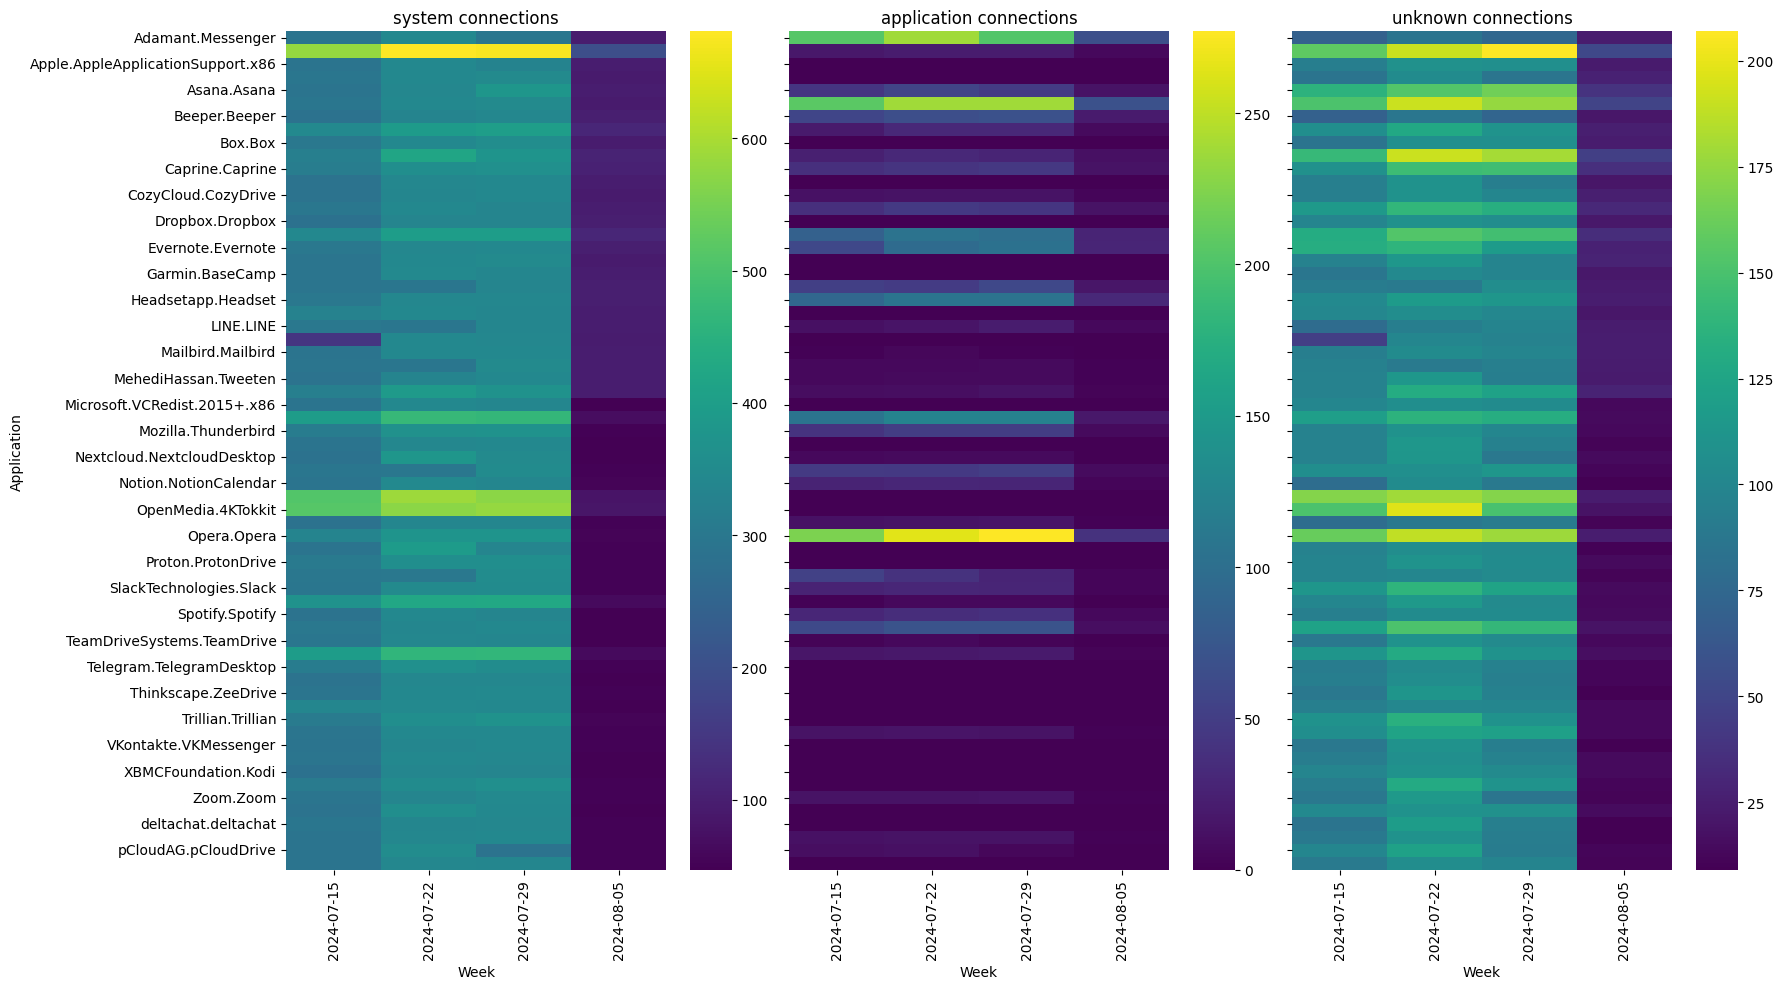

In [16]:
from preact_analysis.plots import plot_3panel_weekly_heatmaps
_=plot_3panel_weekly_heatmaps(weekly, log_scale=False)

## Cardinality of categorical fields (SNI, ALPN, cipher suite, TLS version)

For TLS-related categorical fields like SNI, ALPN, cipher suites, TLS version, we usually want the global cardinality.

In [5]:
import preact_analysis.schema as s
import pandas as pd
fields = s.get_categorical_field_names(s.dataset_schema)

rows = []

for col in fields:
    s = df[col].dropna()

    nunique = s.nunique()
    total = len(df)

    top3 = s.value_counts().head(3)

    # Build structured row
    row = {
        "field": col,
        "cardinality": nunique,
        "total_rows": total,
    }

    for i in range(3):
        if i < len(top3):
            row[f"top{i+1}_value"] = top3.index[i]
            row[f"top{i+1}_freq"] = int(top3.iloc[i])
            row[f"top{i+1}_ratio"] = round(top3.iloc[i] / total, 4)
        else:
            row[f"top{i+1}_value"] = None
            row[f"top{i+1}_freq"] = 0
            row[f"top{i+1}_ratio"] = 0.0

    rows.append(row)

cardinality_df = pd.DataFrame(rows)

# Add overall row count summary
cardinality_df = pd.concat([
    cardinality_df,
    pd.DataFrame([{
        "field": "TOTAL_ROWS",
        "cardinality": len(df),
        "total_rows": len(df)
    }])
], ignore_index=True)

cardinality_df

,field,cardinality,total_rows,top1_value,top1_freq,top1_ratio,top2_value,top2_freq,top2_ratio,top3_value,top3_freq,top3_ratio
0,da,965,100000,4.209.32.67,14480.0,0.1448,4.209.32.198,13796.0,0.1380,4.209.33.156,13391.0,0.1339
1,sa,1156,100000,172.17.159.233,317.0,0.0032,172.17.150.160,312.0,0.0031,172.17.149.163,301.0,0.0030
2,tls.cver,1,100000,0303,100000.0,1.0000,None,0.0,0.0000,None,0.0,0.0000
3,tls.sver,1,100000,0303,99993.0,0.9999,None,0.0,0.0000,None,0.0,0.0000
4,tls.scs,8,100000,C030,79748.0,0.7975,C02C,7079.0,0.0708,1301,6619.0,0.0662
5,tls.sni,314,100000,licensing.mp.microsoft.com,54676.0,0.5468,login.live.com,11258.0,0.1126,go.microsoft.com,7518.0,0.0752
6,tls.ja3,7397,100000,28a2c9bd18a11de089ef85a160da29e4,85629.0,0.8563,a0e9f5d64349fb13191bc781f81f42e1,1690.0,0.0169,b32309a26951912be7dba376398abc3b,1375.0,0.0138
7,tls.ja4,42,100000,t12d1909h2_d83cc789557e_7af1ed941c26,85629.0,0.8563,t13d1516h2_8daaf6152771_02713d6af862,6369.0,0.0637,t12d190800_d83cc789557e_7af1ed941c26,1690.0,0.0169
8,tls.ja3s,70,100000,a39e18564e32e1822751c4af0bfba817,54688.0,0.5469,7d8fd34fdb13a7fff30d5a52846b6c4c,11245.0,0.1124,35af4c8cd9495354f7d701ce8ad7fd2d,7599.0,0.0760
9,tls.ja4s,75,100000,t1205h2_c030_bec8bdbaef8a,54676.0,0.5468,t120400_c030_09f674154ab3,11245.0,0.1124,t1206h1_c030_e1dda4771ae8,7542.0,0.0754


Cardinality Per Application reveals connection parameters diversity per application.

In [15]:
APP_COL = "meta.application.name"

cardinality_per_app = df.groupby(APP_COL)[fields].nunique()   # index = APP_COL

total_connections_per_app = (
    df.groupby(APP_COL)
      .size()
      .rename("connections")     # Series, index = APP_COL
)

cardinality_per_app = (
    cardinality_per_app
    .join(total_connections_per_app)  # joins on index, no overlapping columns
)
cardinality_per_app

,da,sa,tls.cver,tls.sver,tls.scs,tls.sni,tls.ja3,tls.ja4,tls.ja3s,tls.ja4s,meta.sample.id,meta.malware.family,meta.system.os,meta.system.service,meta.application.name,meta.application.process,connections
meta.application.name,,,,,,,,,,,,,,,,,
Adamant.Messenger,64,21,1,1,5,32,713,5,16,16,21,0,1,0,1,5,1989
AirDroid.AirDroid,191,22,1,1,5,50,1320,5,18,18,22,0,1,0,1,6,2808
Apple.AppleApplicationSupport.x86,49,22,1,1,3,9,2,2,11,11,22,0,1,0,1,4,1391
Apple.iTunes,51,22,1,1,3,9,2,2,11,11,22,0,1,0,1,4,1385
Asana.Asana,85,22,1,1,4,16,137,7,15,17,22,0,1,0,1,5,1761
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
agalwood.Motrix,50,21,1,1,4,10,3,3,11,11,21,0,1,0,1,4,1369
deltachat.deltachat,50,21,1,1,3,11,2,2,11,13,21,0,1,0,1,4,1332
eMClient.eMClient,54,21,1,1,3,10,2,2,12,13,21,0,1,0,1,5,1366


# 2. TLS Protocol Characteristics

Distribution of:

* TLS version (1.0–1.3)
* ALPN values (http/1.1, h2, etc.)
* Cipher suites
* Extensions
* SNI presence rate

In [14]:
import pandas as pd
import numpy as np

def _is_null(v) -> bool:
    # robust null check for Python/NumPy/Pandas scalars
    if v is None:
        return True
    try:
        return bool(pd.isna(v))
    except Exception:
        return False

def _is_array_like(v) -> bool:
    # treat list/tuple/ndarray as array-like; exclude strings/bytes
    return isinstance(v, (list, tuple, np.ndarray))

def get_df_tls_array_field_cardinality(df, column:str):
    size = len(df)
    r = (
        df.assign(
            tls_field_str=df[column].apply(
                lambda x: ",".join(x) if x is not None else None
            )
        )
        .groupby("tls_field_str")
        .size()
        .reset_index(name="count")
    )

    r["ratio"] = r["count"] / size
    return r

def get_df_tls_scalar_field_cardinality(df, column):
   size = len(df)
   df_res = (
      df.groupby(column)
         .size()
         .reset_index(name="count")
   )    
   df_res["ratio"] = df_res["count"] / size
   return df_res

def get_df_tls_field_card(df: pd.DataFrame, column: str) -> pd.DataFrame:
    """
    Returns a dataframe with [value, count, ratio] for the given column.
    Automatically handles scalar vs array-like (list/tuple/np.ndarray) columns.
    """
    if column not in df.columns:
        raise KeyError(f"Column '{column}' not found in df")

    s = df[column]

    # infer from first non-null value (works for mixed columns)
    first = next((v for v in s if not _is_null(v)), None)

    if first is None:
        # all nulls -> scalar grouping will yield a single NaN group
        return get_df_tls_scalar_field_cardinality(df, column)

    if _is_array_like(first):
        return get_df_tls_array_field_cardinality(df, column)

    return get_df_tls_scalar_field_cardinality(df, column)

In [15]:
get_df_tls_field_card(df, "tls.cver")


,tls.cver,count,ratio
0,0303,100000,1.0


In [16]:
get_df_tls_field_card(df, "tls.sver")

,tls.sver,count,ratio
0,0303,99993,0.99993


In [17]:
get_df_tls_field_card(df, "tls.alpn")

,tls_field_str,count,ratio
0,,3354,0.03354
1,"h2,http/1.1",96211,0.96211
2,http/1.1,435,0.00435


In [18]:
get_df_tls_field_card(df, "tls.csg")


,tls_field_str,count,ratio
0,"0403,0503,0603,0203,0403,0503,0603,0804,0805,0...",746,0.00746
1,"0403,0503,0603,0804,0805,0806,0401,0501,0601,0...",310,0.00310
2,"0403,0503,0603,0807,0808,0809,080A,080B,0804,0...",470,0.00470
3,"0403,0503,0603,0807,0808,0809,080A,080B,0804,0...",65,0.00065
4,"0403,0503,0603,0807,0808,081A,081B,081C,0809,0...",36,0.00036
5,"0403,0804,0401,0503,0805,0501,0806,0601",9185,0.09185
6,"0403,0804,0401,0503,0805,0501,0806,0601,0201",820,0.00820
7,"0601,0501,0401,0301,0201,0101,0603,0503,0403,0...",7,0.00007
8,"0601,0602,0603,0501,0502,0503,0401,0402,0403,0...",32,0.00032
9,"0603,0601,0503,0501,0403,0401,0402,0203,0201,0202",286,0.00286


In [19]:
get_df_tls_field_card(df, "tls.ccs")

,tls_field_str,count,ratio
0,"0A0A,1301,1302,1303,C02B,C02F,C02C,C030,CCA9,C...",585,0.00585
1,"0A0A,1301,1302,1303,C02B,C02F,C02C,C030,CCA9,C...",20,0.00020
2,"1301,1302,1303,C02F,C02B,C030,C02C,C027,CCA9,C...",350,0.00350
3,"1301,1302,1303,C02F,C02B,C030,C02C,CCA9,CCA8,C...",108,0.00108
4,"1301,1303,1302,C02B,C02F,CCA9,CCA8,C02C,C030,C...",746,0.00746
5,"1302,1301,C02C,C02B,C030,C02F,009F,009E,00FF",44,0.00044
6,"1302,1303,1301,C02C,C030,009F,CCA9,CCA8,CCAA,C...",163,0.00163
7,"1302,1303,1301,C02C,C030,009F,CCA9,CCA8,CCAA,C...",72,0.00072
8,"1302,1303,1301,C02C,C030,C02B,C02F,00A3,009F,0...",40,0.00040
9,"1A1A,1301,1302,1303,C02B,C02F,C02C,C030,CCA9,C...",555,0.00555


In [20]:
get_df_tls_field_card(df, "tls.cext")

,tls_field_str,count,ratio
0,"0000,0005,000A,000B,000D,0023,0010,0017,FF01",85683,0.85683
1,"0000,0005,000A,000B,000D,0023,0017,FF01",1750,0.01750
2,"0000,000A,000B,000D,0023,0010,0017,FF01",175,0.00175
3,"0000,000A,000B,000D,0023,0017,FF01",414,0.00414
4,"0000,000B,000A,0005,0010,0016,0017,0031,000D,0...",44,0.00044
...,...,...,...
7825,"FAFA,FF01,0033,0017,000B,4469,0012,FE0D,002D,0...",1,0.00001
7826,"FAFA,FF01,4469,0000,000D,002D,0010,0017,000B,F...",1,0.00001
7827,"FAFA,FF01,4469,0012,000B,002D,0000,0005,000D,0...",1,0.00001
7828,"FAFA,FF01,4469,001B,0017,002D,0010,000A,0033,0...",1,0.00001


In [21]:
get_df_tls_field_card(df, "tls.ja4")

,tls.ja4,count,ratio
0,t12d130700_677a87942f06_4543037a9dec,7,0.00007
1,t12d1410h2_c866b44c5a26_b5b8faed2b99,310,0.00310
2,t12d190800_d83cc789557e_7af1ed941c26,1690,0.01690
3,t12d1909h2_d83cc789557e_7af1ed941c26,85629,0.85629
4,t12d210700_76e208dd3e22_2dae41c691ec,414,0.00414
5,t12d210800_76e208dd3e22_7af1ed941c26,60,0.00060
6,t12d2108h1_76e208dd3e22_2dae41c691ec,154,0.00154
7,t12d2108h2_76e208dd3e22_2dae41c691ec,21,0.00021
8,t12d2109h1_76e208dd3e22_7af1ed941c26,54,0.00054
9,t12d280700_d943125447b4_3c5a66c06c35,210,0.00210


# 3. Flow-Level Statistics

For each dataset, report summary statistics:

Duration (mean, median, p95, p99)

Bytes up/down

Packet count up/down

Byte ratio up/down

IAT mean / std

Prefer:

Median

IQR

p95/p99
Not only mean (TLS traffic is heavy-tailed).

Also:

% of short connections (<1s)

% of large transfers (>1MB)

# 4. Class Imbalance Overview
For malware datasets:

Connections per family

Families with < 50 connections

Long-tail distribution

Report:

Gini coefficient or simply % from top 10 families

This affects:

Per-family TPR interpretation

Model fairness

# 5. Outlier Audit
Identify:

Top 0.1% longest duration connections

Largest byte transfers

Rare TLS versions

Extremely long record sequences

This helps:

Detect data corruption

Identify edge cases

Understand tails